In [24]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore", category=FutureWarning)

DATA_DIR = Path("data")

train = pd.read_csv(DATA_DIR / "train.csv")
test = pd.read_csv(DATA_DIR / "test_x.csv")

TARGET = "bilissel_performans_skoru"
num_cols = (
    train.select_dtypes(include=np.number)
    .columns.drop(["id", TARGET], errors="ignore")
    .tolist()
)
cat_cols = train.select_dtypes(include="object").columns.tolist()
feature_cols = [c for c in train.columns if c not in {"id", TARGET}]

pd.set_option("display.max_columns", 30)
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["font.size"] = 10

print("train:", train.shape, "| test:", test.shape)

train: (56000, 24) | test: (24000, 23)


/tmp/ipykernel_233657/2092435742.py:22: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = train.select_dtypes(include="object").columns.tolist()


# Uyku & bilişsel performans — keşifsel veri analizi (EDA)


In [25]:
train.head()

,id,yas,cinsiyet,meslek,vucut_kitle_indeksi,ulke,rem_yuzdesi,derin_uyku_yuzdesi,uykuya_dalma_suresi_dk,gecelik_uyanma_sayisi,uyku_oncesi_kafein_mg,uyku_oncesi_ekran_suresi_dk,gunluk_adim_sayisi,sekerleme_suresi_dk,stres_skoru,gunluk_calisma_saati,kronotip,ruh_sagligi_durumu,dinlenik_nabiz_bpm,oda_sicakligi_celsius,hafta_sonu_uyku_farki_saat,mevsim,gun_tipi,bilissel_performans_skoru
0,1,34,Erkek,Saglik Personeli,31.470103,Cin,14.431210,14.645436,27,7,0.0,97,7184,0,9.922976,10.045274,Sabah insani,Anksiyete ve depresyon,78,18.962436,-0.074140,Sonbahar-Kis,Hafta ici,0.136441
1,2,32,Kadin,Muhendis,30.981394,Amerika,21.771870,27.220360,20,4,4.0,180,5057,1,6.626400,6.319245,Gece insani,Saglikli,76,21.225666,0.942672,Sonbahar-Kis,Hafta ici,5.848312
2,3,39,Erkek,Ev Hanimi,21.533898,Spain,18.178857,25.530104,33,7,148.0,23,10816,70,6.093566,3.824463,Notr,Depresyon,66,18.482409,1.239886,Ilkbahar-Yaz,Hafta sonu,6.828276
3,4,40,Kadin,Egitimci,23.310749,Yeni Zelanda,21.438151,15.891188,21,2,0.0,180,5238,115,3.168185,4.597316,Gece insani,Saglikli,60,21.862235,0.727695,Sonbahar-Kis,Hafta sonu,8.144649
4,5,36,Kadin,NaN,NaN,Portekiz,25.468018,16.356738,21,8,100.0,145,4042,0,7.198574,3.189120,Notr,Anksiyete ve depresyon,74,19.223195,-0.223402,Sonbahar-Kis,Hafta ici,0.431423


In [26]:
print(train.shape)
print(test.shape)

(56000, 24)
(24000, 23)


In [27]:
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 56000 entries, 0 to 55999
Data columns (total 24 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   id                           56000 non-null  int64  
 1   yas                          56000 non-null  int64  
 2   cinsiyet                     56000 non-null  str    
 3   meslek                       54622 non-null  str    
 4   vucut_kitle_indeksi          54248 non-null  float64
 5   ulke                         56000 non-null  str    
 6   rem_yuzdesi                  56000 non-null  float64
 7   derin_uyku_yuzdesi           56000 non-null  float64
 8   uykuya_dalma_suresi_dk       56000 non-null  int64  
 9   gecelik_uyanma_sayisi        56000 non-null  int64  
 10  uyku_oncesi_kafein_mg        54537 non-null  float64
 11  uyku_oncesi_ekran_suresi_dk  56000 non-null  int64  
 12  gunluk_adim_sayisi           56000 non-null  int64  
 13  sekerleme_suresi_dk        

In [28]:
train.isnull().sum().sort_values(ascending=False)

kronotip                       1968
vucut_kitle_indeksi            1752
stres_skoru                    1715
uyku_oncesi_kafein_mg          1463
meslek                         1378
ruh_sagligi_durumu             1096
yas                               0
id                                0
derin_uyku_yuzdesi                0
rem_yuzdesi                       0
ulke                              0
cinsiyet                          0
uyku_oncesi_ekran_suresi_dk       0
gunluk_adim_sayisi                0
gecelik_uyanma_sayisi             0
uykuya_dalma_suresi_dk            0
gunluk_calisma_saati              0
sekerleme_suresi_dk               0
dinlenik_nabiz_bpm                0
oda_sicakligi_celsius             0
hafta_sonu_uyku_farki_saat        0
mevsim                            0
gun_tipi                          0
bilissel_performans_skoru         0
dtype: int64

In [29]:
missing_ratio = (
    train.isnull().sum() / len(train)
) * 100

missing_ratio.sort_values(ascending=False)

kronotip                       3.514286
vucut_kitle_indeksi            3.128571
stres_skoru                    3.062500
uyku_oncesi_kafein_mg          2.612500
meslek                         2.460714
ruh_sagligi_durumu             1.957143
yas                            0.000000
id                             0.000000
derin_uyku_yuzdesi             0.000000
rem_yuzdesi                    0.000000
ulke                           0.000000
cinsiyet                       0.000000
uyku_oncesi_ekran_suresi_dk    0.000000
gunluk_adim_sayisi             0.000000
gecelik_uyanma_sayisi          0.000000
uykuya_dalma_suresi_dk         0.000000
gunluk_calisma_saati           0.000000
sekerleme_suresi_dk            0.000000
dinlenik_nabiz_bpm             0.000000
oda_sicakligi_celsius          0.000000
hafta_sonu_uyku_farki_saat     0.000000
mevsim                         0.000000
gun_tipi                       0.000000
bilissel_performans_skoru      0.000000
dtype: float64

### Eksik değerler

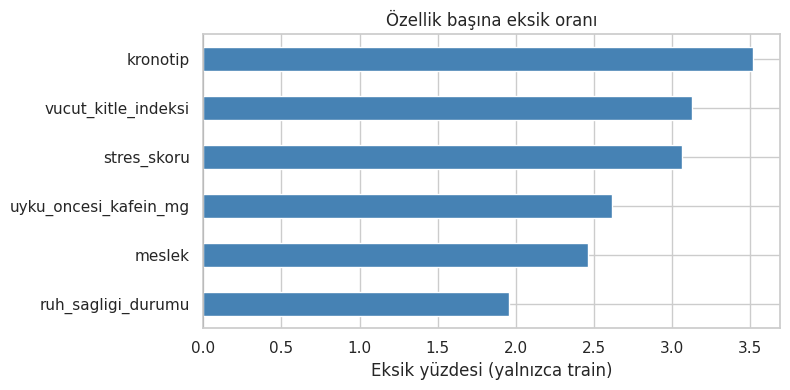

In [30]:
miss_pct = train[feature_cols].isnull().mean().sort_values(ascending=False) * 100
miss_pct = miss_pct[miss_pct > 0]

fig, ax = plt.subplots(figsize=(8, max(4, 0.35 * len(miss_pct))))
miss_pct.iloc[::-1].plot(kind="barh", ax=ax, color="steelblue")
ax.axvline(0, color="k", lw=0.5)
ax.set_xlabel("Eksik yüzdesi (yalnızca train)")
ax.set_title("Özellik başına eksik oranı")
plt.tight_layout()
plt.show()

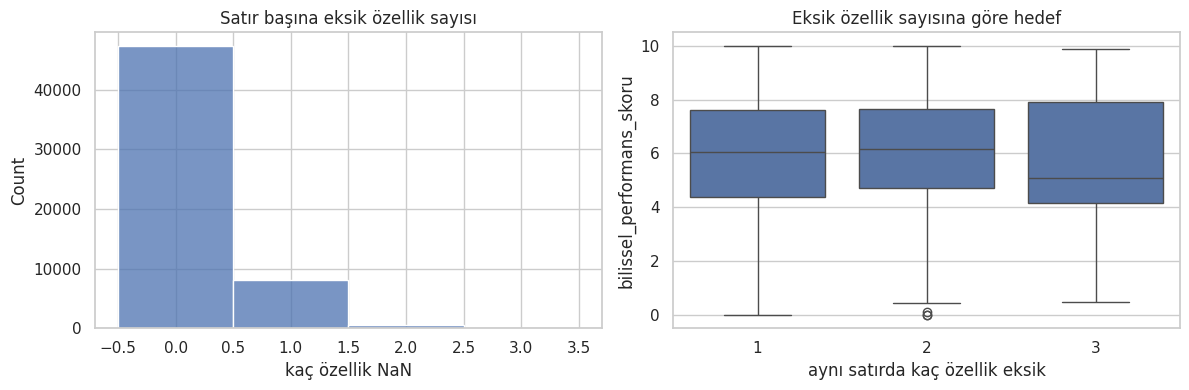

En az bir eksik özelliği olan satır oranı (train): 15.62%


In [31]:
row_miss = train[feature_cols].isnull().sum(axis=1)
tdf = train.assign(_row_miss=row_miss).query("_row_miss > 0")

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(row_miss, discrete=True, ax=ax[0])
ax[0].set_title("Satır başına eksik özellik sayısı")
ax[0].set_xlabel("kaç özellik NaN")

if len(tdf):
    sns.boxplot(data=tdf, x="_row_miss", y=TARGET, ax=ax[1])
    ax[1].set_title("Eksik özellik sayısına göre hedef")
    ax[1].set_xlabel("aynı satırda kaç özellik eksik")
else:
    ax[1].set_visible(False)

plt.tight_layout()
plt.show()

print(f"En az bir eksik özelliği olan satır oranı (train): {(row_miss.gt(0).mean()*100):.2f}%")

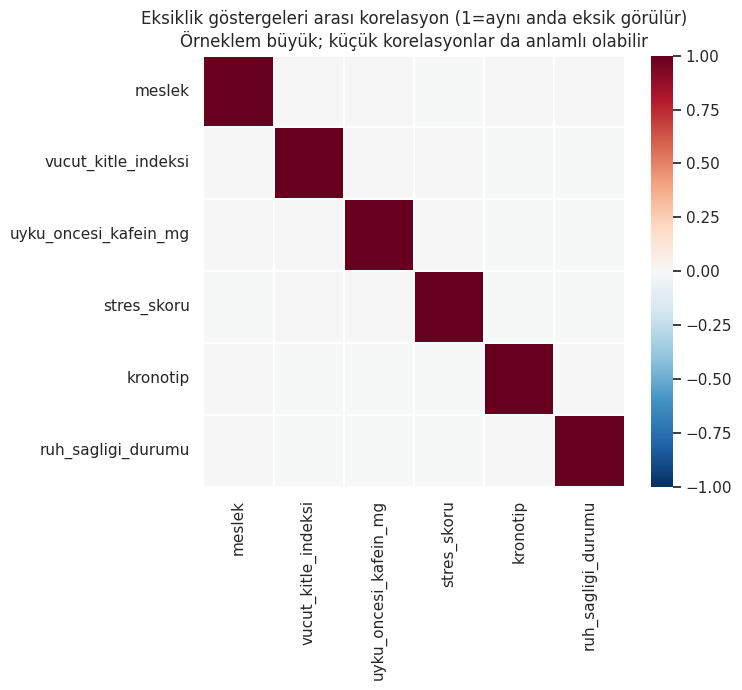

In [32]:
mcols = [c for c in feature_cols if train[c].isnull().any()]
M = train[mcols].isnull().astype(np.float32)
co = M.corr()

plt.figure(figsize=(7.5, 7))
sns.heatmap(co, cmap="RdBu_r", center=0, vmin=-1, vmax=1, linewidths=0.3)
plt.title("Eksiklik göstergeleri arası korelasyon (1=aynı anda eksik görülür)\nÖrneklem büyük; küçük korelasyonlar da anlamlı olabilir")
plt.tight_layout()
plt.show()

## Eksik değer özeti

Yukarıda çizilen grafiklerle: **hangi sütunda** eksik var, **aynı satırda** birden fazla eksik oluyor mu, eksikler **birlikte** mı görünüyor — gözlemlendi.

Oranlar genelde **%2–3** bandında; bu yüzden sütun silmek yerine **imputation** (ve gerekirse “eksik mi?” ikili işareti) tipik yaklaşım olur — imputasyon kodu burada değil, ayrı “feature pipeline” notunda yazılır.

In [33]:
# Veri kalitesi: id tekilliği, satır tekrarı, train–test id çakışması
assert train["id"].is_unique, "Train id tekilleşmemiş"
assert test["id"].is_unique, "Test id tekilleşmemiş"

train_test_id_overlap = np.intersect1d(train["id"].values, test["id"].values).size
print("Train ile test arasında ortak id sayısı:", train_test_id_overlap)

n_dup_feature_rows = train[feature_cols].duplicated().sum()
print("Özellik alanında birebir aynı tekrarlayan satır sayısı:", int(n_dup_feature_rows))

Train ile test arasında ortak id sayısı: 24000
Özellik alanında birebir aynı tekrarlayan satır sayısı: 0


### Hedef değişken ve sayısallarla ilişki

Regresyon metriği (**RMSE** vb.) küçültmeye yardımcı olabilecek sütunlara kabaca öncelik vermek için: dağılım, tanısal korelasyon, ısı haritası ve birkaç serpilme grafiği. Ağaç modeller doğrusallık aramaz; bu bölüm yine de **hangi blokları daha çok işlemek gerektiği** için yol gösterir.

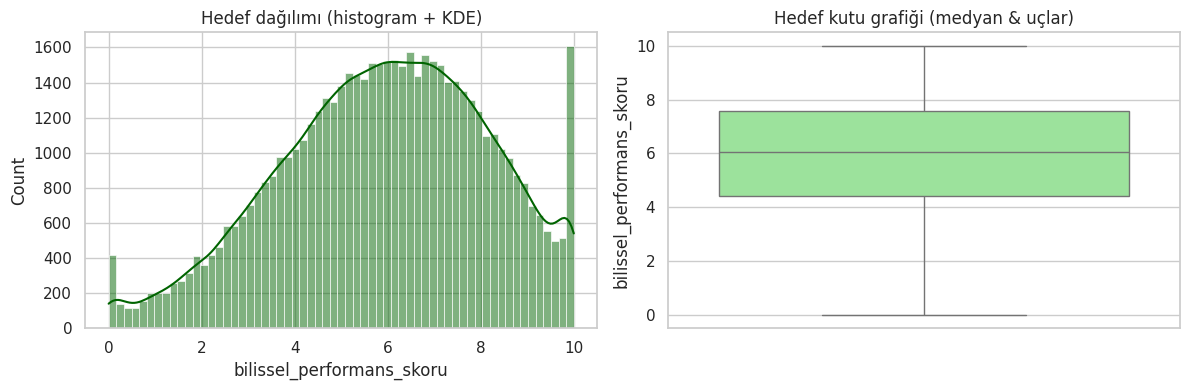

,count,mean,std,min,25%,50%,75%,max
bilissel_performans_skoru,56000.0,5.913096,2.231759,0.0,4.397431,6.032249,7.57498,10.0


Çarpıklık (skew): -0.2885
Basıklık (excess kurtosis): -0.4340


,pearson_hedef
stres_skoru,-0.5867
rem_yuzdesi,0.4430
gunluk_calisma_saati,-0.3421
derin_uyku_yuzdesi,0.2800
gecelik_uyanma_sayisi,-0.2703
uykuya_dalma_suresi_dk,-0.2073
gunluk_adim_sayisi,0.1340
dinlenik_nabiz_bpm,-0.0894
yas,-0.0707
uyku_oncesi_kafein_mg,-0.0624


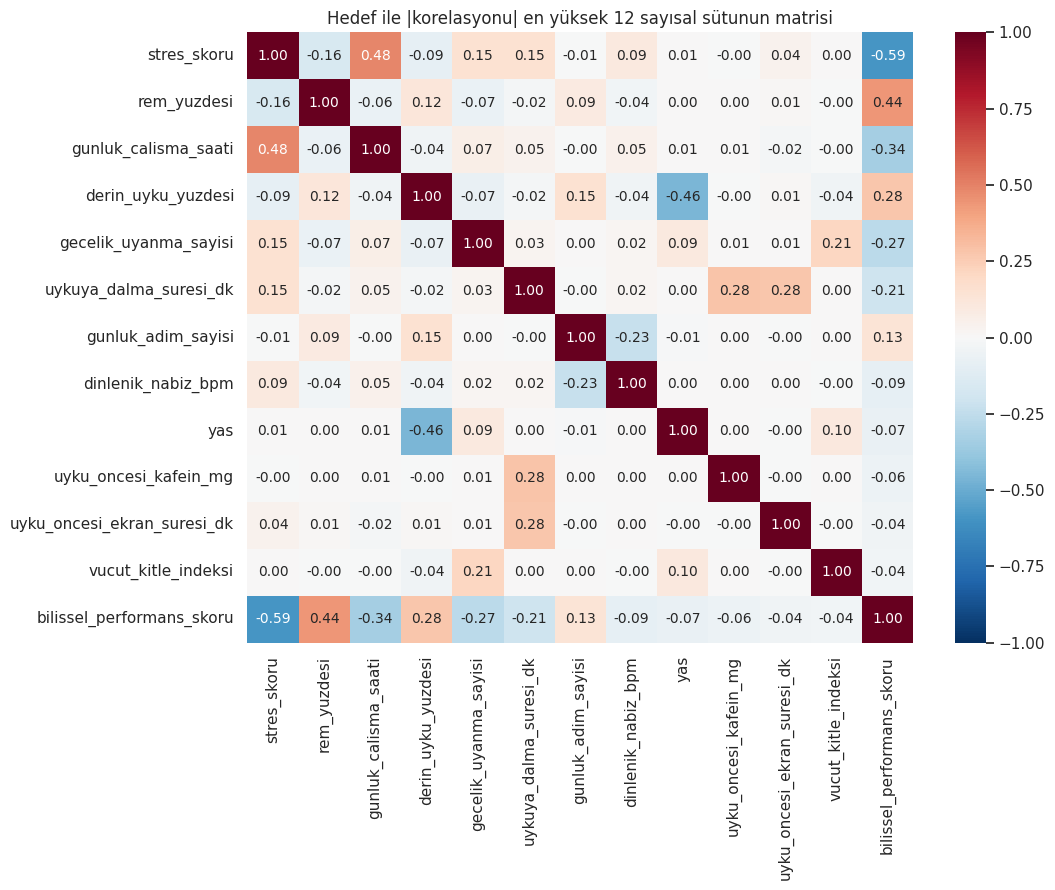

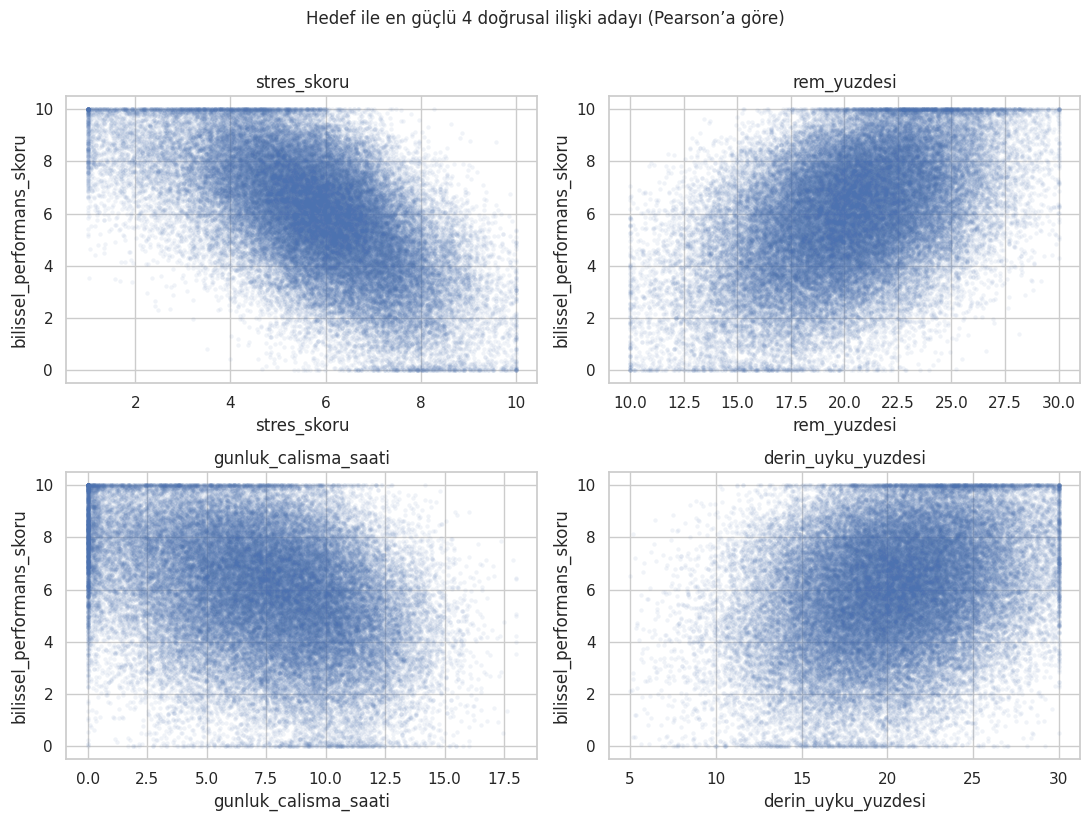

,count,mean,std,min,25%,50%,75%,max
yas,56000.0,34.714,11.053,18.0,26.000,33.000,42.000,69.0
vucut_kitle_indeksi,54248.0,26.274,4.495,16.0,23.175,26.226,29.322,45.0
rem_yuzdesi,56000.0,20.234,3.443,10.0,17.952,20.302,22.598,30.0
derin_uyku_yuzdesi,56000.0,20.246,4.300,5.0,17.338,20.292,23.227,30.0
uykuya_dalma_suresi_dk,56000.0,20.108,8.063,1.0,14.000,20.000,25.000,58.0
gecelik_uyanma_sayisi,56000.0,3.345,2.035,0.0,2.000,3.000,5.000,8.0
uyku_oncesi_kafein_mg,54537.0,42.111,72.154,0.0,0.000,3.000,77.000,400.0
uyku_oncesi_ekran_suresi_dk,56000.0,63.511,44.591,2.0,30.000,51.000,84.000,180.0
gunluk_adim_sayisi,56000.0,7493.198,3462.699,500.0,5042.000,7426.000,9876.000,20000.0
sekerleme_suresi_dk,56000.0,15.433,21.105,0.0,0.000,2.000,30.000,115.0


In [34]:
# --- Hedef (bilissel performans skoru) ---
y = train[TARGET]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(y, kde=True, ax=axes[0], color="darkgreen")
axes[0].set_title("Hedef dağılımı (histogram + KDE)")
sns.boxplot(y=y, ax=axes[1], color="lightgreen")
axes[1].set_title("Hedef kutu grafiği (medyan & uçlar)")

plt.tight_layout()
plt.show()

from IPython.display import display

display(y.describe().to_frame().T)
print(f"Çarpıklık (skew): {y.skew():.4f}")
print(f"Basıklık (excess kurtosis): {y.kurtosis():.4f}")

# --- Sayısallarla Pearson: hedefle doğrusal ilişki ipucu (tek başına yeterli değil) ---
pearson = train[num_cols + [TARGET]].corr(numeric_only=True)[TARGET].drop(TARGET)
pearson = pearson.sort_values(key=np.abs, ascending=False)
display(pearson.round(4).to_frame("pearson_hedef"))

# En güçlü 12 özellik + hedef arasında korelasyon ısı haritası (çok doğrusallık yokmuş gibi kullanmayın)
k_heat = list(pearson.abs().nlargest(min(12, len(pearson))).index)
cm = train[k_heat + [TARGET]].corr(numeric_only=True)

plt.figure(figsize=(11, 9))
sns.heatmap(cm, annot=True, fmt=".2f", cmap="RdBu_r", center=0, vmin=-1, vmax=1)
plt.title("Hedef ile |korelasyonu| en yüksek 12 sayısal sütunun matrisi")
plt.tight_layout()
plt.show()

# En üst sıradan 4 özellik: hedefe serpilme (şeffaflıkla çok nokta)
top4 = pearson.abs().nlargest(min(4, len(pearson))).index.tolist()
fig, axes = plt.subplots(2, 2, figsize=(11, 8))
axes = axes.ravel()
for ax, col in zip(axes, top4):
    sns.scatterplot(data=train, x=col, y=TARGET, ax=ax, alpha=0.08, s=10, linewidth=0)
    ax.set_title(col)
plt.suptitle("Hedef ile en güçlü 4 doğrusal ilişki adayı (Pearson’a göre)", y=1.02)
plt.tight_layout()
plt.show()

# Tüm sayısallara genel bakış istatistikleri
display(train[num_cols].describe().T.round(3))

Train ve test özellik sütunlarında eksik değer oranları benzer mi, model doğrulanırken sapma oluşturur mu diye yan yana kontrol edilecek.

In [35]:
tr_miss = train[feature_cols].isnull().mean()
te_miss = test[feature_cols].isnull().mean()
missing_compare = pd.concat([tr_miss, te_miss], axis=1, keys=["train_miss_rate", "test_miss_rate"])
missing_compare["fark_abs"] = (missing_compare["train_miss_rate"] - missing_compare["test_miss_rate"]).abs()
missing_compare.sort_values("train_miss_rate", ascending=False).round(4)

,train_miss_rate,test_miss_rate,fark_abs
kronotip,0.0351,0.0347,0.0005
vucut_kitle_indeksi,0.0313,0.0270,0.0043
stres_skoru,0.0306,0.0319,0.0013
uyku_oncesi_kafein_mg,0.0261,0.0290,0.0029
meslek,0.0246,0.0259,0.0013
ruh_sagligi_durumu,0.0196,0.0210,0.0014
rem_yuzdesi,0.0000,0.0000,0.0000
ulke,0.0000,0.0000,0.0000
yas,0.0000,0.0000,0.0000
cinsiyet,0.0000,0.0000,0.0000


### Train vs test — seçili sayısalların dağılımı

Aynı kod imputation veya modelda sapma yaratmasın diye test setinin **benzer aralıkta** olup olmadığına bakıyoruz (KDE üst üste).

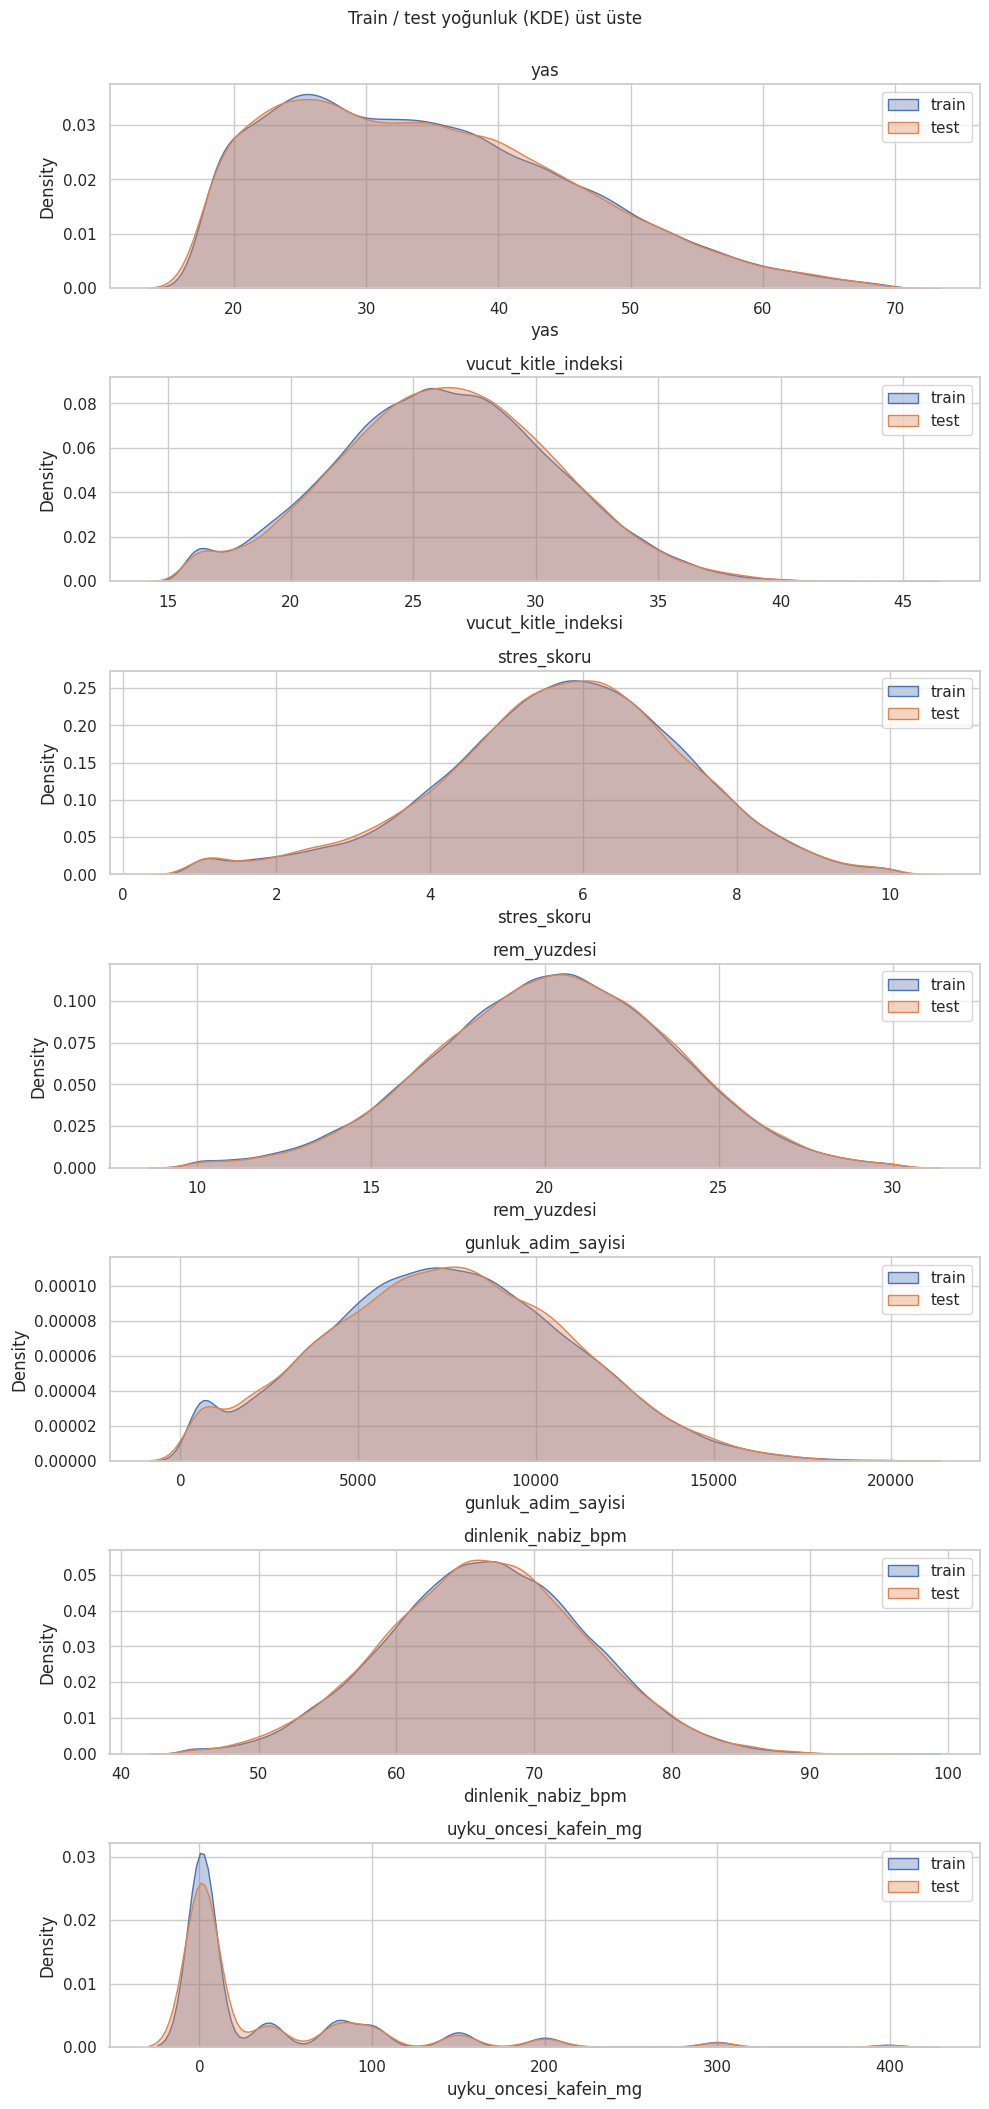

In [36]:
karsilastirilan = (
    ["yas", "vucut_kitle_indeksi", "stres_skoru", "rem_yuzdesi"]
    + ["gunluk_adim_sayisi", "dinlenik_nabiz_bpm", "uyku_oncesi_kafein_mg"]
)
karsilastirilan = [c for c in karsilastirilan if c in num_cols]

fig, axes = plt.subplots(
    len(karsilastirilan),
    1,
    figsize=(10, max(10, len(karsilastirilan) * 3)),
)
if len(karsilastirilan) == 1:
    axes = [axes]
for ax, c in zip(axes, karsilastirilan):
    sns.kdeplot(train[c].dropna(), ax=ax, label="train", fill=True, alpha=0.35)
    sns.kdeplot(test[c].dropna(), ax=ax, label="test", fill=True, alpha=0.35)
    ax.set_title(c)
    ax.legend()

plt.suptitle("Train / test yoğunluk (KDE) üst üste", y=1.002)
plt.tight_layout()
plt.show()

### Aykırı değerlere “tanısal” bakış (IQR kuralı)

Burada **henüz silmiyoruz / kesmiyoruz**. Klasik kutu grafiği çizilirken kullanılan IQR göre: değer `Q1 - 1.5×IQR` altında veya `Q3 + 1.5×IQR` üstündeyse “uç gözlem adayı” sayılıyor; **her özellik için yüzde kaç satır böyle** tablo + grafik olarak veriliyor.

Ağaç modellerinde uçların etkisi farklı; yine de **hangi özellik gürültülü**, rapor etmek yararlıdır. Gerçek müdahale (winsorize, transform) ayrı karar ve aynı dönüşüm train+test pipeline’ına yazılır.

,% satir_ucda
uyku_oncesi_kafein_mg,6.16
uyku_oncesi_ekran_suresi_dk,5.88
stres_skoru,1.82
uykuya_dalma_suresi_dk,0.95
sekerleme_suresi_dk,0.90
rem_yuzdesi,0.75
dinlenik_nabiz_bpm,0.54
derin_uyku_yuzdesi,0.42
yas,0.33
vucut_kitle_indeksi,0.32


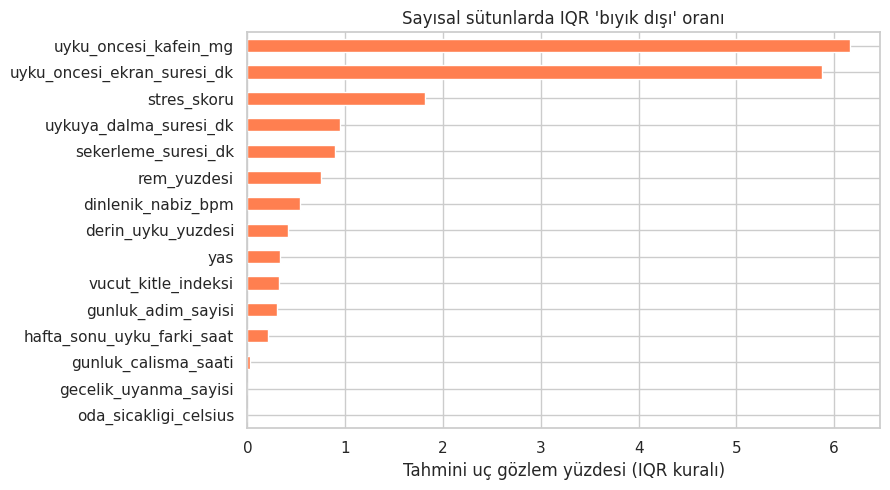

Üst sıradaki özelliklere özellikle boxplot ile tekrar bakın; gerekiyorsa log dönüşümü veya kırpmayı sonra kararlaştırın.


In [37]:
def iqr_outlier_rate(s: pd.Series) -> float:
    """Kutu grafiği bıyığı dışına düşen gözlem oranı (kabaca tanısal uç yüzdesi)."""
    v = s.dropna()
    if v.empty:
        return np.nan
    q1, q3 = v.quantile(0.25), v.quantile(0.75)
    iqr = q3 - q1
    if iqr == 0:
        return np.nan
    lo, hi = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    return float(((v < lo) | (v > hi)).mean())


out_rates = pd.Series({c: iqr_outlier_rate(train[c]) for c in num_cols}, name="iqr_uc_orani")

df_out = out_rates.dropna().sort_values(ascending=False).multiply(100).round(2).to_frame("% satir_ucda")
display(df_out)

fig, ax = plt.subplots(figsize=(9, max(5, 0.32 * len(df_out))))
df_out.iloc[::-1].plot(kind="barh", ax=ax, color="coral", legend=False)
ax.set_xlabel("Tahmini uç gözlem yüzdesi (IQR kuralı)")
ax.set_title("Sayısal sütunlarda IQR 'bıyık dışı' oranı")
plt.tight_layout()
plt.show()

print("Üst sıradaki özelliklere özellikle boxplot ile tekrar bakın; gerekiyorsa log dönüşümü veya kırpmayı sonra kararlaştırın.")

### Kategorik değişkenler

- **Kardinalite:** Kaç farklı sınıf var (train ve test ayrı)?
- **Hedefe göre dağılım:** Kutu grafikleri medyan ve yayılımı gösterir (sınıflar arası fark var mı).
- **Sürpriz test kategorileri:** Testte görünüp trainde hiç olmayan etiket varsa, encoding stratejisinde `unknown` veya fold içi hedef encoding gibi düşünmek gerekir.

,sutun,train_nuniq,test_nuniq,train_miss,test_miss
2,ulke,15,15,0.0000,0.0000
1,meslek,12,12,0.0246,0.0259
4,ruh_sagligi_durumu,5,5,0.0196,0.0210
3,kronotip,4,4,0.0351,0.0347
0,cinsiyet,2,2,0.0000,0.0000
5,mevsim,2,2,0.0000,0.0000
6,gun_tipi,2,2,0.0000,0.0000


--- Sadece bir tarafta görünen kategorik düzeyler (varsa detay) ---
(Tüm kategoriklerde train ve test düzey kümeleri NaN hariç örtüşüyor gibi.)


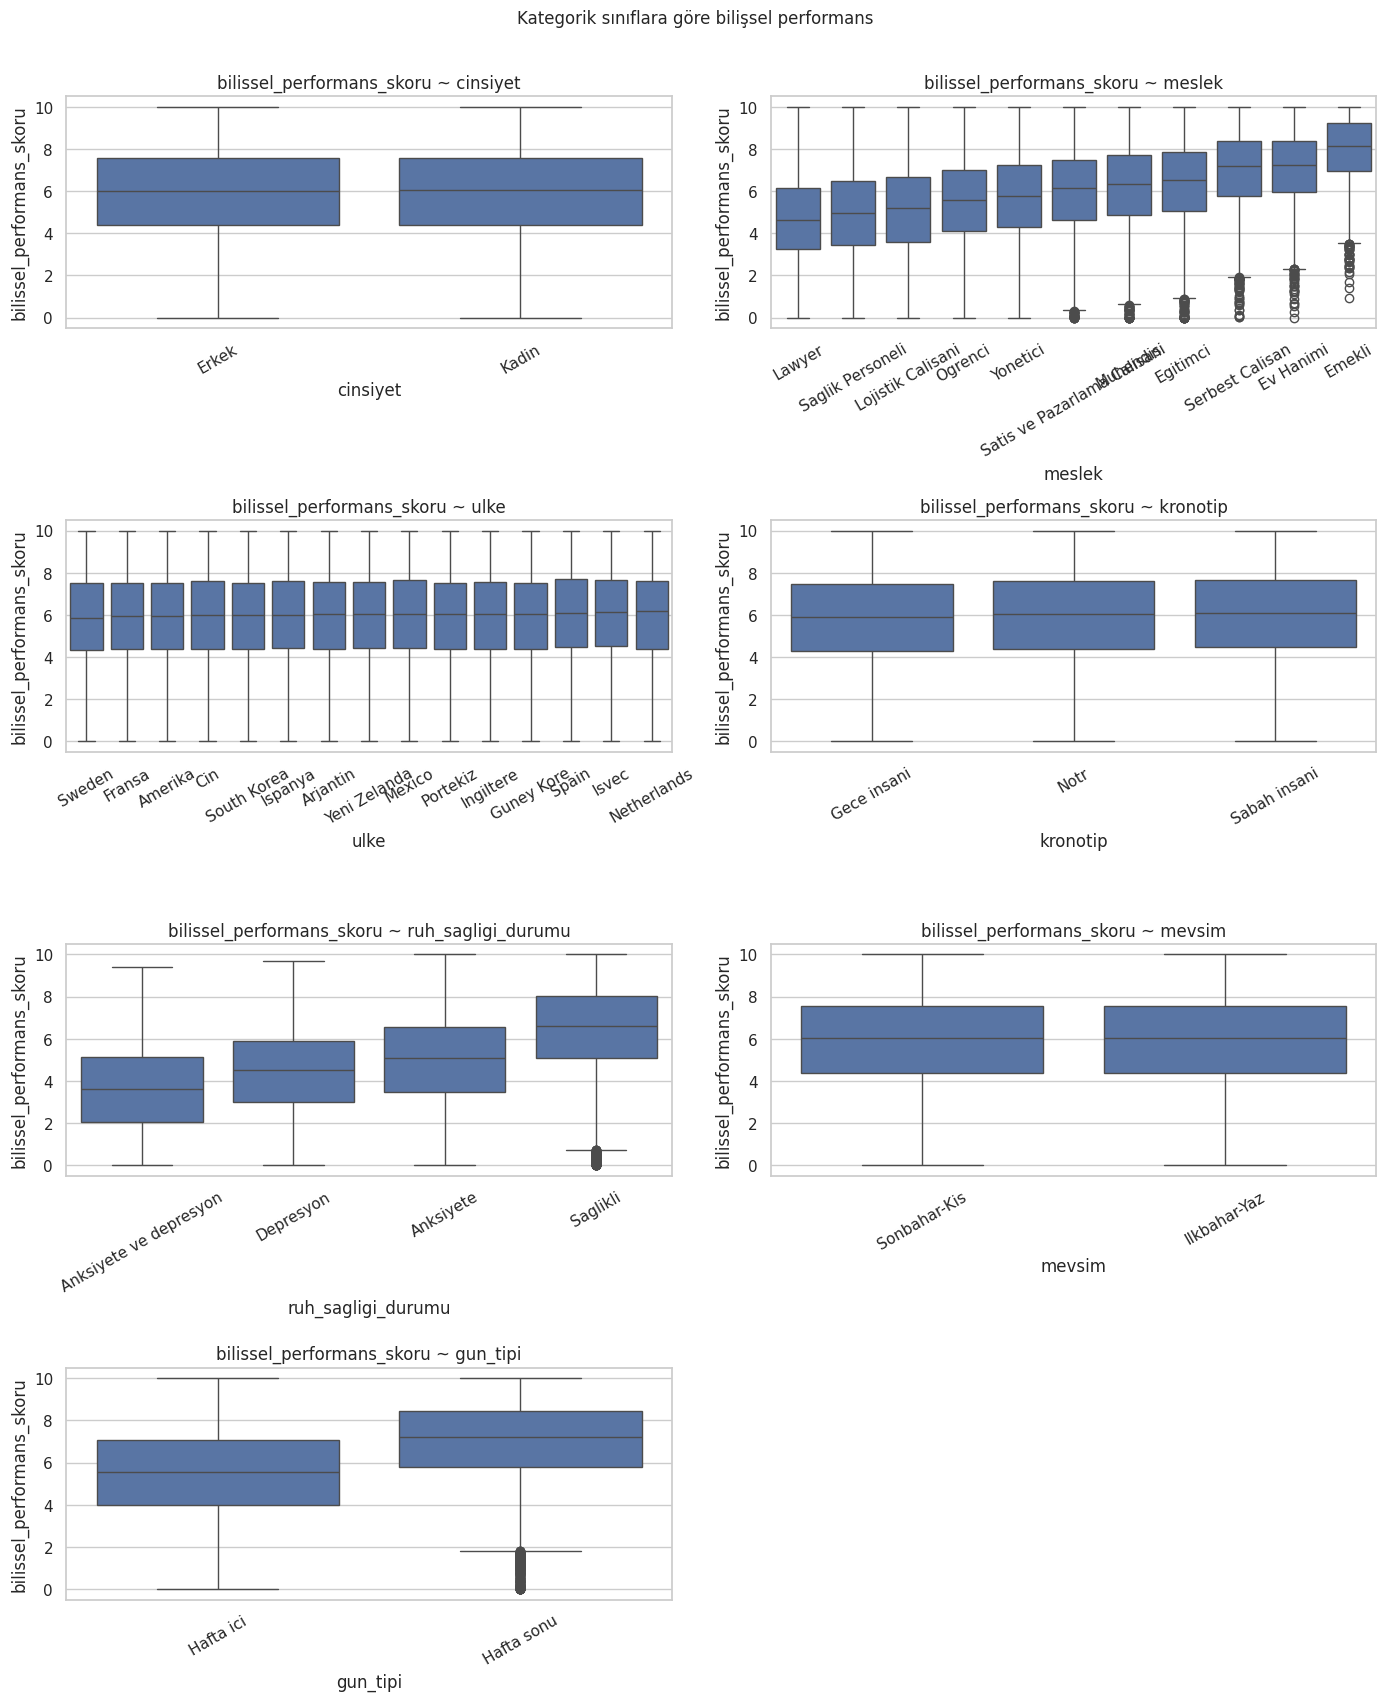

In [38]:
rows = []
for c in cat_cols:
    rows.append({
        "sutun": c,
        "train_nuniq": train[c].nunique(dropna=False),
        "test_nuniq": test[c].nunique(dropna=False),
        "train_miss": train[c].isnull().mean(),
        "test_miss": test[c].isnull().mean(),
    })
summ = pd.DataFrame(rows).sort_values("train_nuniq", ascending=False)
display(summ.round(4))

print("--- Sadece bir tarafta görünen kategorik düzeyler (varsa detay) ---")
gorduk = False
for c in cat_cols:
    tr_lv = set(train[c].dropna().unique())
    te_lv = set(test[c].dropna().unique())
    only_te = te_lv - tr_lv
    only_tr = tr_lv - te_lv
    if only_te or only_tr:
        gorduk = True
        print(f"\n{c}:")
        if only_te:
            print(f"  Yalnızca testte ({len(only_te)} adet), örnek: {list(only_te)[:6]}")
        if only_tr:
            print(f"  Yalnızca trainde ({len(only_tr)} adet), örnek: {list(only_tr)[:6]}")
if not gorduk:
    print("(Tüm kategoriklerde train ve test düzey kümeleri NaN hariç örtüşüyor gibi.)")

# Hedefe göre kutu grafikleri (medyana göre sıralı sınıflar)
n_cat = len(cat_cols)
ncol = 2
nrow = int(np.ceil(n_cat / ncol))
fig, axes = plt.subplots(nrow, ncol, figsize=(14, 4.2 * nrow))
axes = np.atleast_1d(axes).ravel()

for idx, c in enumerate(cat_cols):
    ax = axes[idx]
    sub = train.dropna(subset=[c])
    order = sub.groupby(c, observed=True)[TARGET].median().sort_values().index
    sns.boxplot(data=sub, x=c, y=TARGET, order=order, ax=ax)
    ax.tick_params(axis="x", rotation=30)
    ax.set_title(f"{TARGET} ~ {c}")

for j in range(idx + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Kategorik sınıflara göre bilişsel performans", y=1.01)
plt.tight_layout()
plt.show()

## Özellik mühendisliği (taslak hipotezler)

Raporda modelleme ekibine iletilmesi gereken yapı blokları örnek olarak:

| Blok | Sütunlar | Not |
|------|----------|-----|
| Uyku kalitesi özeti | `rem_yuzdesi`, `derin_uyku_yuzdesi`, `gecelik_uyanma_sayisi`, `uykuya_dalma_suresi_dk` | Oranların toplanması / uyku süresinin olmamasına dikkat; basit bileşik skorlar veya etkileşim |
| Stres-yük dengesi | `stres_skoru`, `gunluk_calisma_saati` | Örn. iş yükü baskısı = stres × çalışma saati |
| Dijital & hareket | `uyku_oncesi_ekran_suresi_dk`, `gunluk_adim_sayisi` | Ekran/az hareket senaryoları için oranlar |
| Fizik & ortam | `vucut_kitle_indeksi`, `dinlenik_nabiz_bpm`, `oda_sicakligi_celsius` | Nabız uyarı işareti olarak kullanılabilir |

Nihai dönüşümleri **aynı kodun train/test’te** çalıştırılması (fit edilen istatistiklerle) şartını unutmayın.


# Yapılan İşlemlerin Genel Özeti

Bu notebook kapsamında veri üzerinde doğrudan modelleme yapılmamış; veri yapısını anlamaya ve modelleme aşamasına yön verecek keşifsel veri analizi (EDA) gerçekleştirilmiştir.

Gerçekleştirilen başlıca adımlar:
- Hedef değişken (`bilissel_performans_skoru`) tanımlandı.
- Sayısal ve kategorik değişkenler ayrıştırıldı.
- Veri setlerinin boyutları ve değişken tipleri incelendi.
- İlk gözlemler (`head`) üzerinden veri yapısı kontrol edildi.

## Eksik Değer Analizi

- Her sütundaki eksik gözlem sayıları hesaplandı.
- Eksik değer oranları yüzde olarak incelendi.
- Eksik değerlerin train ve test veri setlerinde benzer dağılım gösterip göstermediği kontrol edildi.
- Satır bazında aynı anda birden fazla eksik değer bulunup bulunmadığı analiz edildi.
- Eksiklik göstergeleri arasındaki ilişkiler korelasyon ısı haritası ile görselleştirildi.

Bu aşamada eksik değerler henüz doldurulmamış, yalnızca yapısal inceleme yapılmıştır.

## Hedef Değişken Analizi

- Hedef değişkenin dağılımı histogram ve kutu grafiği ile incelendi.
- Tanımlayıcı istatistikler hesaplandı.
- Çarpıklık (skewness) ve basıklık (kurtosis) değerleri değerlendirildi.

## Sayısal Değişken Analizi

- Sayısal değişkenlerin özet istatistikleri incelendi.
- Hedef değişken ile Pearson korelasyonları hesaplandı.
- En güçlü ilişkiler korelasyon matrisi ve ısı haritası ile görselleştirildi.
- Hedef ile en yüksek ilişkiye sahip değişkenler için serpilme grafikleri oluşturuldu.

## Train – Test Dağılım Karşılaştırması

- Seçili sayısal değişkenlerde train ve test veri setlerinin dağılımları KDE grafikleri ile karşılaştırıldı.
- Büyük bir dağılım kayması (distribution shift) olup olmadığı kontrol edildi.

## Aykırı Değer (Outlier) İncelemesi

- Sayısal değişkenlerde IQR yöntemi kullanılarak yaklaşık aykırı gözlem oranları hesaplandı.
- Aykırı gözlem oranları tablo ve grafiklerle raporlandı.

Bu aşamada aykırı değerler üzerinde henüz doğrudan bir işlem yapılmamış; yalnızca tanısal inceleme gerçekleştirilmiştir.

## Kategorik Değişken Analizi

- Kategorik değişkenlerin sınıf sayıları incelendi.
- Train ve test veri setlerinde kategori uyumu kontrol edildi.
- Test setinde yalnızca teste özgü kategori bulunup bulunmadığı analiz edildi.
- Kategorik değişkenlerin hedef değişken üzerindeki dağılımları kutu grafikleri ile görselleştirildi.

## Feature Engineering İçin İlk Fikirler

EDA sürecinde aşağıdaki olası feature engineering fikirleri not edilmiştir:

- Uyku kalitesi skoru
- Stres ve çalışma yükü etkileşimi
- Dijital yorgunluk göstergeleri
- Uyku bölünmesi / uyku bozulma skorları
- Fiziksel aktivite ve toparlanma dengesi

Bu notebook’un amacı veri üzerinde nihai dönüşümleri uygulamak değil; modelleme ekibine veri davranışı, potansiyel riskler ve güçlü değişkenler hakkında yön gösterici içgörüler sağlamaktır.

# Genel EDA Özeti ve Bulgular

Bu notebook kapsamında veri üzerinde doğrudan modelleme yapılmamış, veri yapısını anlamaya ve modelleme aşamasına yön verecek keşifsel veri analizi (EDA) gerçekleştirilmiştir. İlk aşamada train ve test veri setleri içe aktarılmış, hedef değişken olarak `bilissel_performans_skoru` tanımlanmış ve sayısal ile kategorik değişkenler ayrıştırılmıştır. Veri seti incelendiğinde train verisinin 56.000 gözlem ve 24 sütundan, test verisinin ise 24.000 gözlem ve 23 sütundan oluştuğu görülmüştür. Veri tipleri kontrol edilmiş, veri setinde hem sayısal hem kategorik değişkenlerin bulunduğu doğrulanmıştır.

Eksik değer analizi kapsamında her sütundaki eksik gözlem sayıları ve oranları incelenmiştir. En yüksek eksik oranlarının `kronotip` (%3.51), `vucut_kitle_indeksi` (%3.13), `stres_skoru` (%3.06), `uyku_oncesi_kafein_mg` (%2.61), `meslek` (%2.46) ve `ruh_sagligi_durumu` (%1.96) değişkenlerinde olduğu görülmüştür. Genel olarak eksik oranlarının düşük seviyede kaldığı gözlenmiştir. Satır bazında yapılan incelemede gözlemlerin yaklaşık %15.6’sında en az bir eksik değer bulunduğu görülmüş, ancak eksik değerlerin aynı satırlarda yoğun şekilde kümelenmediği anlaşılmıştır. Eksiklik göstergeleri arasında oluşturulan korelasyon ısı haritası da güçlü bir eksiklik birlikteliği olmadığını göstermiştir. Bu durum, eksik değerlerin büyük ölçüde rastgele dağılmış olabileceğini düşündürmüş ve kolon silmek yerine uygun imputasyon yöntemlerinin daha mantıklı olabileceğine işaret etmiştir.

Hedef değişken analizi sırasında `bilissel_performans_skoru` değişkeninin dağılımı histogram, KDE eğrisi ve kutu grafikleri ile incelenmiştir. Ortalama değerin yaklaşık 5.91, medyanın ise 6.03 olduğu görülmüştür. Çarpıklık değeri -0.2885, basıklık değeri ise -0.4340 olarak hesaplanmıştır. Dağılımın yaklaşık normal yapıya yakın olduğu, aşırı çarpık veya uç değerlere aşırı duyarlı bir hedef yapısı bulunmadığı gözlenmiştir. Bu nedenle hedef değişken üzerinde doğrudan bir dönüşüm uygulanmasının zorunlu olmayabileceği düşünülmüştür.

Sayısal değişkenlerle hedef değişken arasındaki ilişkiler Pearson korelasyon katsayıları ile incelenmiştir. En güçlü negatif ilişkinin `stres_skoru` değişkeninde (-0.5867) olduğu görülmüştür. Bunun yanında `gunluk_calisma_saati`, `gecelik_uyanma_sayisi` ve `uykuya_dalma_suresi_dk` değişkenlerinin de bilişsel performans ile negatif ilişki gösterdiği gözlemlenmiştir. Pozitif tarafta ise `rem_yuzdesi` (0.4430), `derin_uyku_yuzdesi` (0.2800) ve `gunluk_adim_sayisi` (0.1340) değişkenlerinin öne çıktığı görülmüştür. Bu bulgular genel olarak uyku kalitesi arttıkça bilişsel performansın yükseldiğini, stres ve yoğun çalışma yükünün ise performansı düşürebileceğini göstermektedir. Korelasyon matrisi ve serpilme grafikleri kullanılarak bu ilişkiler görselleştirilmiş ve özellikle stres ile REM yüzdesinin modelleme açısından önemli aday değişkenler olabileceği düşünülmüştür.

Train ve test veri setlerinin dağılımlarının benzer olup olmadığını incelemek amacıyla seçili sayısal değişkenlerde KDE karşılaştırmaları yapılmıştır. Yaş, vücut kitle indeksi, stres skoru, REM yüzdesi, günlük adım sayısı, dinlenik nabız ve uyku öncesi kafein tüketimi gibi değişkenlerde train ve test yoğunluk eğrilerinin büyük ölçüde benzer olduğu görülmüştür. Bu durum, veri setleri arasında ciddi bir distribution shift olmadığını ve modelin train verisinden öğrendiği örüntüleri test veri setinde de kullanabileceğini düşündürmektedir.

Aykırı değer incelemesi IQR yöntemi kullanılarak gerçekleştirilmiştir. En yüksek yaklaşık aykırı gözlem oranlarının `uyku_oncesi_kafein_mg` (%6.16) ve `uyku_oncesi_ekran_suresi_dk` (%5.88) değişkenlerinde olduğu görülmüştür. `stres_skoru` değişkeninde ise yaklaşık %1.82 oranında aykırı gözlem tespit edilmiştir. Bununla birlikte bu gözlemlerin gerçek yaşam davranışlarını temsil etme ihtimali bulunduğundan, mevcut aşamada doğrudan silme işlemi uygulanmamıştır. Özellikle kafein tüketimi ve ekran süresinin sağa çarpık dağılım gösterebileceği düşünülmüş, modelleme aşamasında gerekirse log dönüşümü veya clipping gibi yöntemlerin değerlendirilebileceği not edilmiştir.

Kategorik değişken analizi kapsamında train ve test veri setleri arasında kategori uyumu incelenmiştir. Test veri setinde train’de bulunmayan yeni kategorilere rastlanmamıştır. Bu durum encoding süreçleri açısından olumlu değerlendirilmiştir. Kategorik değişkenlerin hedef değişken üzerindeki etkileri kutu grafikleri ile incelenmiş ve özellikle `ruh_sagligi_durumu`, `meslek` ve `gun_tipi` değişkenlerinin bilişsel performansı ayırma potansiyeli taşıdığı gözlenmiştir. Bazı kategoriler arasında hedef dağılımının belirgin şekilde farklılaştığı görülmüştür.

EDA süreci boyunca modelleme ekibine iletilebilecek çeşitli feature engineering fikirleri de not edilmiştir. Uyku kalitesi için REM yüzdesi, derin uyku yüzdesi ve gece uyanma sayısını birleştiren bileşik skorlar; stres ve çalışma yükünü bir araya getiren etkileşim değişkenleri; ekran süresi ve kafein tüketimine dayalı dijital yorgunluk göstergeleri; uyku bölünmesini temsil eden yeni skorlar ve fiziksel aktivite ile toparlanma dengesini ölçebilecek birleşik özellikler olası geliştirme alanları olarak değerlendirilmiştir.

Genel olarak değerlendirildiğinde veri setinin kullanılabilir ve büyük ölçüde tutarlı bir yapıda olduğu, eksik değer oranlarının düşük seviyede kaldığı, train ve test veri dağılımlarının birbirine benzer olduğu ve özellikle stres, uyku kalitesi ile çalışma yükünün bilişsel performans üzerinde belirgin etkiler gösterebildiği gözlenmiştir. Bu notebook’un temel amacı model kurmak değil; veri davranışını anlamak, olası riskleri belirlemek ve modelleme ekibine anlamlı feature alanları konusunda yön gösterici içgörüler sağlamaktır.

## Eksik Değerlerin Hedef Değişkenle İlişkisi
    
Bu tablo bize şunu gösterecek:

kronotip eksik olanların hedef ortalaması kaç?
kronotip eksik olmayanların hedef ortalaması kaç?

In [39]:
missing_cols = [col for col in feature_cols if train[col].isnull().any()]

missing_target_summary = []

for col in missing_cols:
    temp = train.copy()
    temp[f"{col}_missing"] = temp[col].isnull().astype(int)

    summary = temp.groupby(f"{col}_missing")[TARGET].agg(
        count="count",
        mean="mean",
        median="median",
        std="std"
    ).reset_index()

    summary["column"] = col
    missing_target_summary.append(summary)

missing_target_summary = pd.concat(missing_target_summary, ignore_index=True)
missing_target_summary

,meslek_missing,count,mean,median,std,column,vucut_kitle_indeksi_missing,uyku_oncesi_kafein_mg_missing,stres_skoru_missing,kronotip_missing,ruh_sagligi_durumu_missing
0,0.0,54622,5.910325,6.029780,2.229726,meslek,NaN,NaN,NaN,NaN,NaN
1,1.0,1378,6.022928,6.141325,2.309071,meslek,NaN,NaN,NaN,NaN,NaN
2,NaN,54248,5.913175,6.030743,2.230778,vucut_kitle_indeksi,0.0,NaN,NaN,NaN,NaN
3,NaN,1752,5.910648,6.067616,2.262574,vucut_kitle_indeksi,1.0,NaN,NaN,NaN,NaN
4,NaN,54537,5.915119,6.035178,2.233030,uyku_oncesi_kafein_mg,NaN,0.0,NaN,NaN,NaN
5,NaN,1463,5.837662,5.948668,2.183254,uyku_oncesi_kafein_mg,NaN,1.0,NaN,NaN,NaN
6,NaN,54285,5.911677,6.030685,2.232760,stres_skoru,NaN,NaN,0.0,NaN,NaN
7,NaN,1715,5.958010,6.078345,2.200027,stres_skoru,NaN,NaN,1.0,NaN,NaN
8,NaN,54032,5.909330,6.027233,2.231686,kronotip,NaN,NaN,NaN,0.0,NaN
9,NaN,1968,6.016487,6.144591,2.231868,kronotip,NaN,NaN,NaN,1.0,NaN


## Kutu Grafik ile gösterimi
Burada x ekseninde:
    0 = eksik değil
    1 = eksik
olacak.

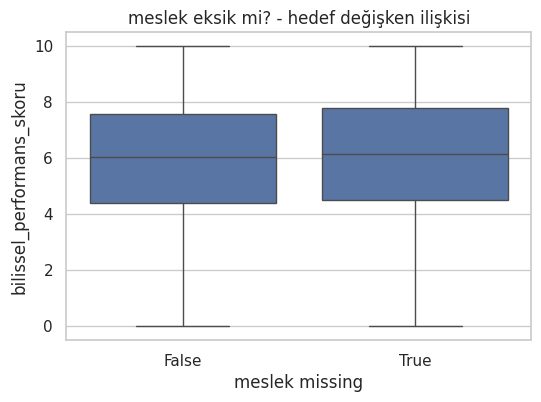

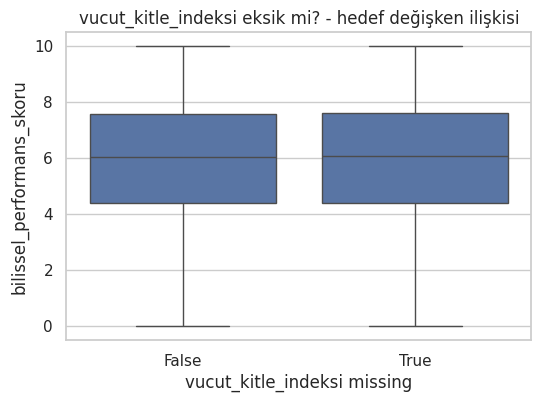

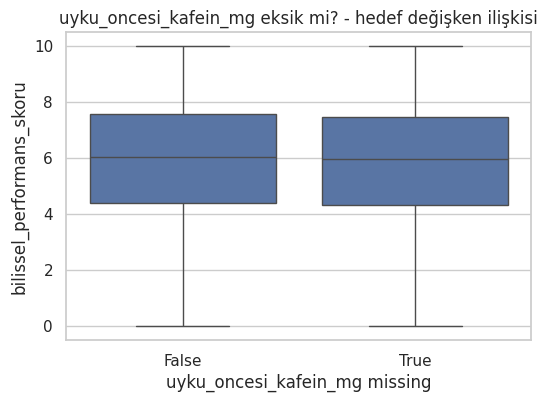

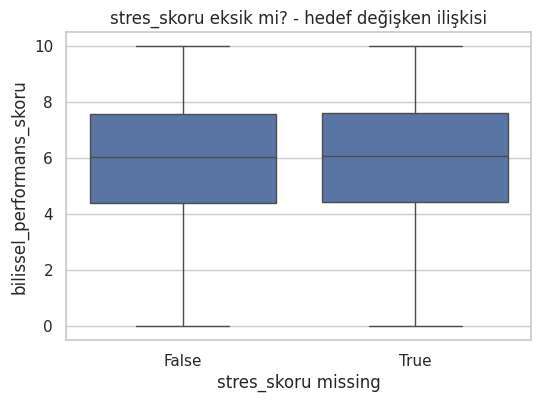

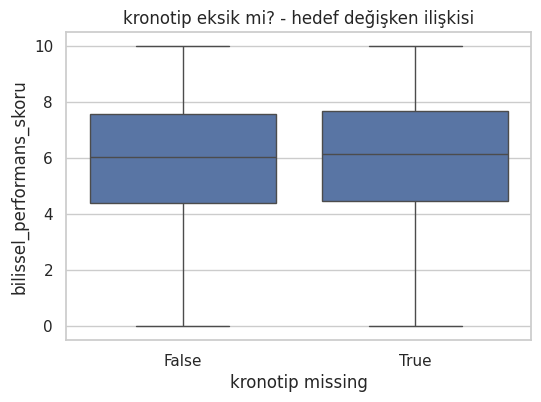

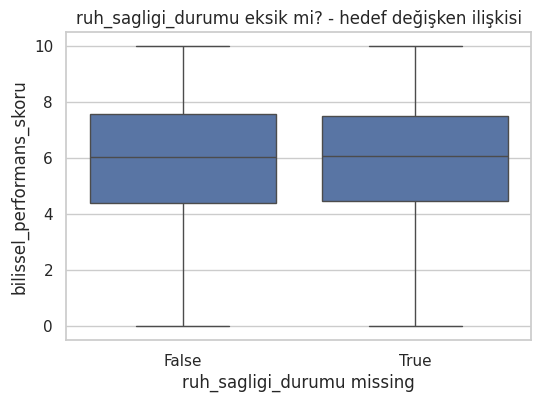

In [40]:
for col in missing_cols:
    temp = train.copy()
    temp[f"{col}_missing"] = temp[col].isnull().astype("category")

    plt.figure(figsize=(6, 4))
    sns.boxplot(
        data=temp,
        x=f"{col}_missing",
        y=TARGET
    )
    plt.title(f"{col} eksik mi? - hedef değişken ilişkisi")
    plt.xlabel(f"{col} missing")
    plt.ylabel(TARGET)
    plt.show()

## Kategorik Değişkenlerin Hedef Değişkenle İlişkisi

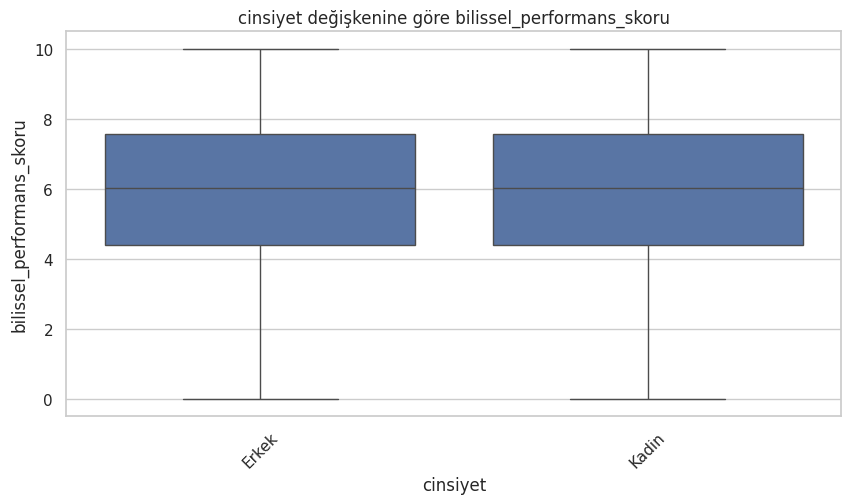

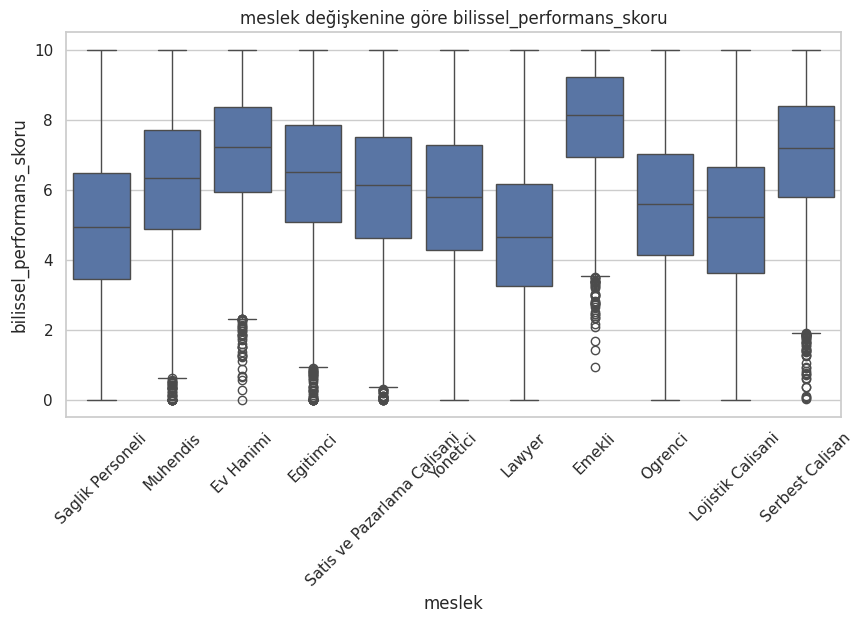

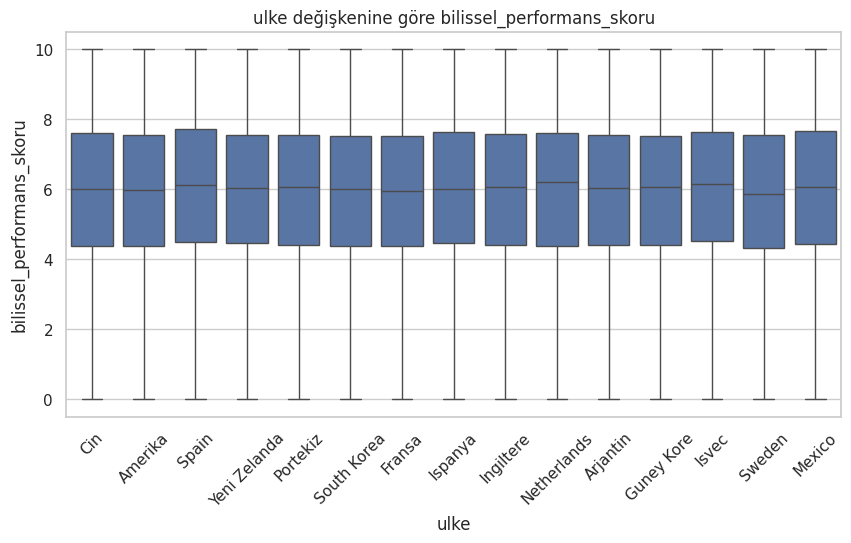

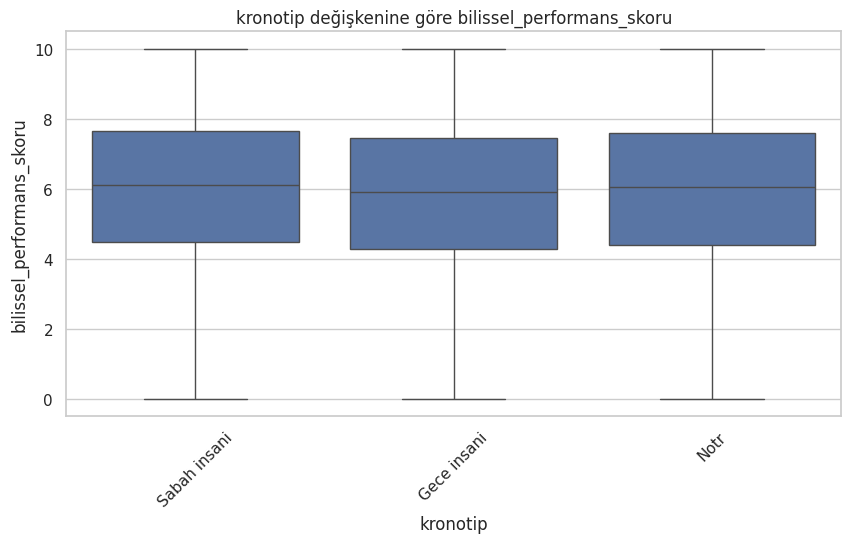

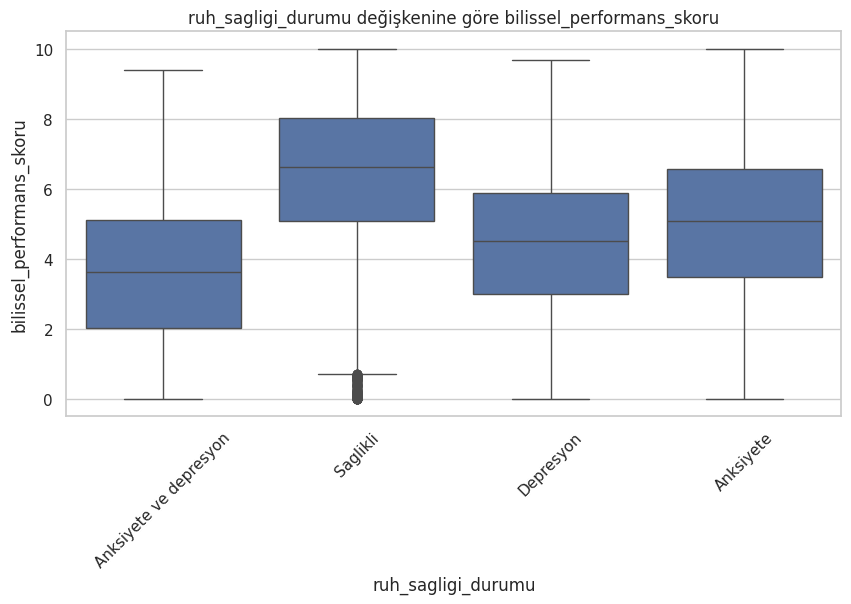

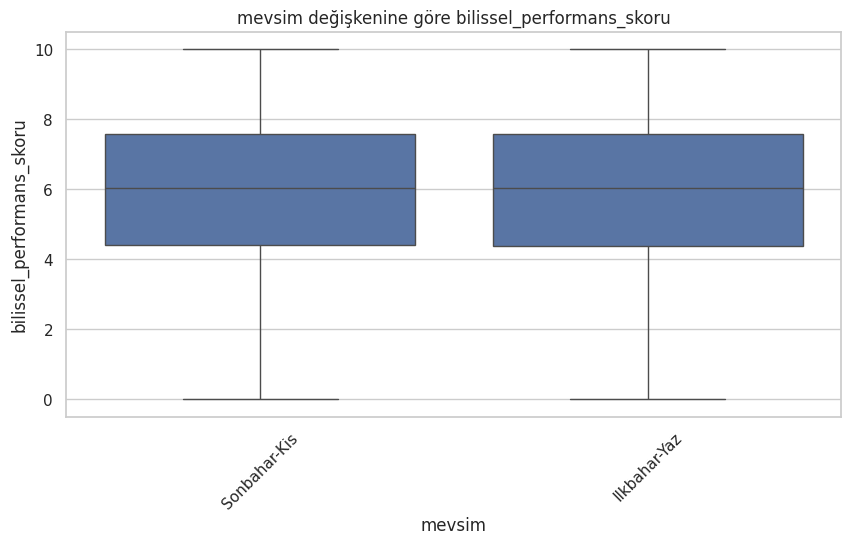

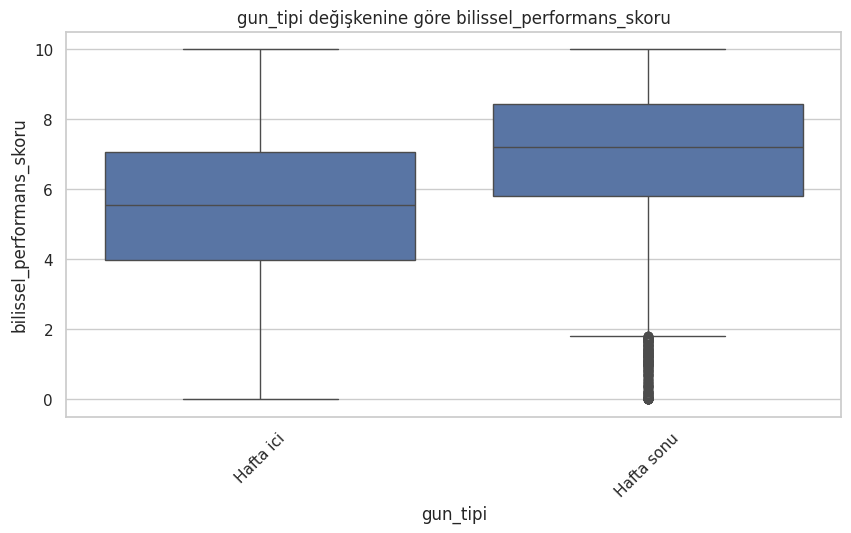

In [41]:
for col in cat_cols:
    plt.figure(figsize=(10, 5))
    sns.boxplot(
        data=train,
        x=col,
        y=TARGET
    )
    plt.title(f"{col} değişkenine göre {TARGET}")
    plt.xticks(rotation=45)
    plt.show()

## Tablo gösterimi

In [42]:
cat_target_summary = []

for col in cat_cols:
    summary = train.groupby(col, dropna=False)[TARGET].agg(
        count="count",
        mean="mean",
        median="median",
        std="std"
    ).reset_index()

    summary["column"] = col
    cat_target_summary.append(summary)

cat_target_summary = pd.concat(cat_target_summary, ignore_index=True)
cat_target_summary

,cinsiyet,count,mean,median,std,column,meslek,ulke,kronotip,ruh_sagligi_durumu,mevsim,gun_tipi
0,Erkek,27324,5.913804,6.029780,2.224613,cinsiyet,NaN,NaN,NaN,NaN,NaN,NaN
1,Kadin,28676,5.912420,6.034980,2.238586,cinsiyet,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,4395,6.343725,6.506638,2.011186,meslek,Egitimci,NaN,NaN,NaN,NaN,NaN
3,NaN,3778,7.935044,8.140140,1.608945,meslek,Emekli,NaN,NaN,NaN,NaN,NaN
4,NaN,3224,7.055969,7.234872,1.802786,meslek,Ev Hanimi,NaN,NaN,NaN,NaN,NaN
5,NaN,2742,4.719782,4.647024,2.125938,meslek,Lawyer,NaN,NaN,NaN,NaN,NaN
6,NaN,3811,5.119135,5.218837,2.166604,meslek,Lojistik Calisani,NaN,NaN,NaN,NaN,NaN
7,NaN,6533,6.223087,6.327394,2.040621,meslek,Muhendis,NaN,NaN,NaN,NaN,NaN
8,NaN,8132,5.535248,5.601813,2.111092,meslek,Ogrenci,NaN,NaN,NaN,NaN,NaN
9,NaN,9842,4.930272,4.945638,2.190316,meslek,Saglik Personeli,NaN,NaN,NaN,NaN,NaN


## Sayısal Değişkenlerin Hedef Değişkenle İlişkisi

In [43]:
corr_with_target = train[num_cols + [TARGET]].corr(numeric_only=True)[TARGET]
corr_with_target = corr_with_target.drop(TARGET).sort_values(key=abs, ascending=False)

corr_with_target.to_frame("correlation_with_target")

,correlation_with_target
stres_skoru,-0.586676
rem_yuzdesi,0.442999
gunluk_calisma_saati,-0.342112
derin_uyku_yuzdesi,0.280006
gecelik_uyanma_sayisi,-0.270349
uykuya_dalma_suresi_dk,-0.207349
gunluk_adim_sayisi,0.134042
dinlenik_nabiz_bpm,-0.089389
yas,-0.070659
uyku_oncesi_kafein_mg,-0.062387


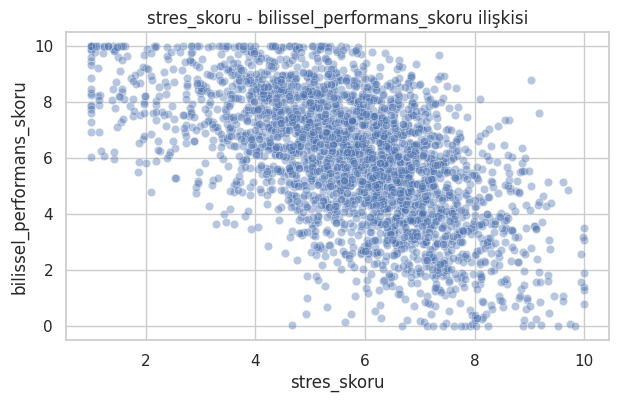

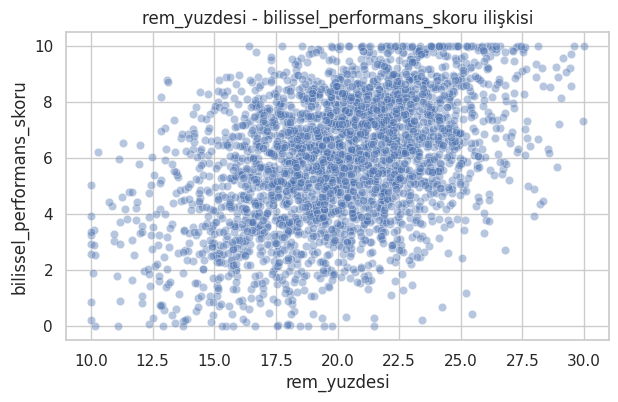

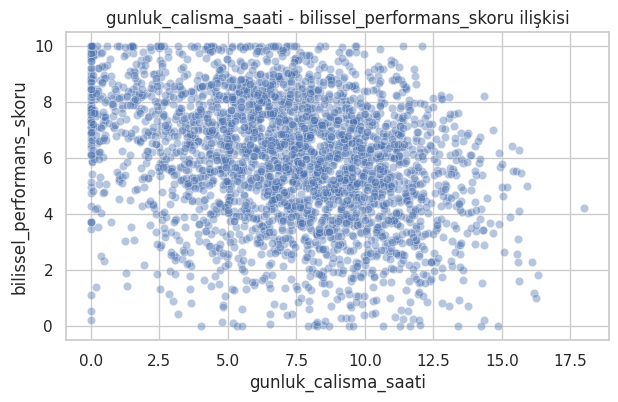

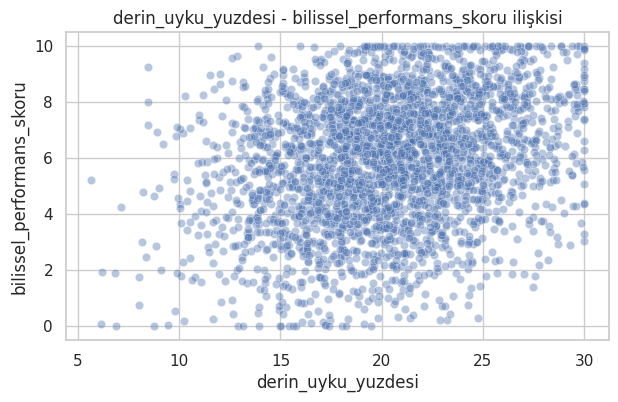

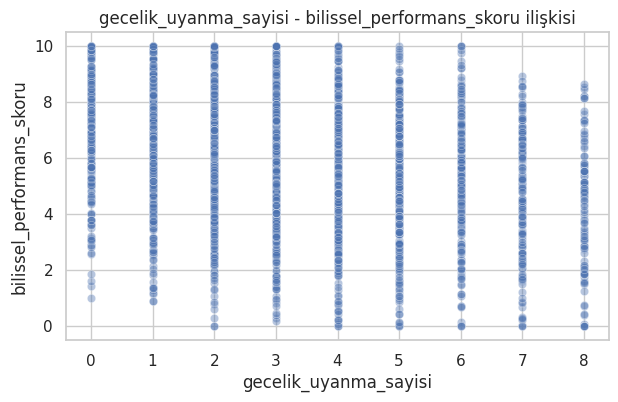

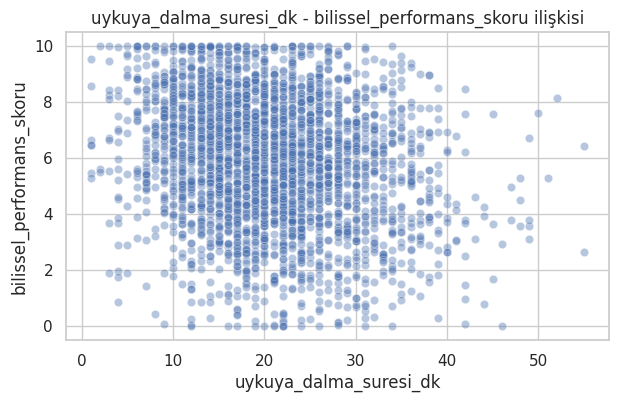

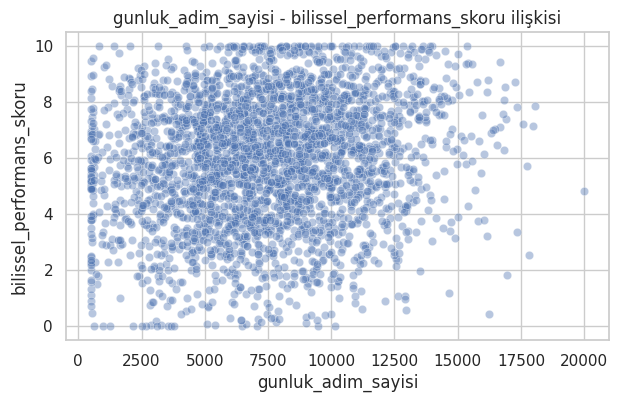

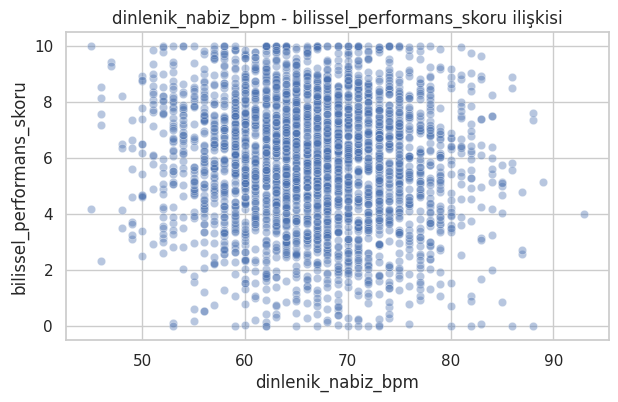

In [44]:
top_num_cols = corr_with_target.head(8).index.tolist()

for col in top_num_cols:
    plt.figure(figsize=(7, 4))
    sns.scatterplot(
        data=train.sample(min(3000, len(train)), random_state=42),
        x=col,
        y=TARGET,
        alpha=0.4
    )
    plt.title(f"{col} - {TARGET} ilişkisi")
    plt.show()

## Train-Test Dağılım Karşılaştırması

In [45]:
train_test_compare = []

for col in num_cols:
    train_test_compare.append({
        "column": col,
        "train_mean": train[col].mean(),
        "test_mean": test[col].mean(),
        "mean_diff": abs(train[col].mean() - test[col].mean()),
        "train_median": train[col].median(),
        "test_median": test[col].median(),
        "median_diff": abs(train[col].median() - test[col].median()),
        "train_std": train[col].std(),
        "test_std": test[col].std(),
        "std_diff": abs(train[col].std() - test[col].std())
    })

train_test_compare = pd.DataFrame(train_test_compare)
train_test_compare.sort_values("mean_diff", ascending=False)

,column,train_mean,test_mean,mean_diff,train_median,test_median,median_diff,train_std,test_std,std_diff
8,gunluk_adim_sayisi,7493.197554,7516.762917,23.565363,7426.000000,7485.000000,59.000000,3462.699361,3462.578765,0.120596
6,uyku_oncesi_kafein_mg,42.110952,42.361885,0.250933,3.000000,3.000000,0.000000,72.154159,72.477832,0.323672
9,sekerleme_suresi_dk,15.432875,15.322667,0.110208,2.000000,2.000000,0.000000,21.104672,21.115702,0.011031
12,dinlenik_nabiz_bpm,66.603214,66.515250,0.087964,67.000000,67.000000,0.000000,7.353174,7.388835,0.035660
1,vucut_kitle_indeksi,26.273651,26.354491,0.080840,26.225806,26.351529,0.125723,4.495138,4.455273,0.039865
0,yas,34.714446,34.662125,0.052321,33.000000,33.000000,0.000000,11.052508,11.044303,0.008205
3,derin_uyku_yuzdesi,20.246063,20.292365,0.046302,20.292151,20.385155,0.093004,4.300421,4.258140,0.042280
2,rem_yuzdesi,20.233500,20.278214,0.044714,20.302218,20.332256,0.030038,3.442993,3.424471,0.018522
4,uykuya_dalma_suresi_dk,20.107536,20.063833,0.043702,20.000000,20.000000,0.000000,8.063278,8.050903,0.012375
11,gunluk_calisma_saati,7.156456,7.123312,0.033144,7.360860,7.343444,0.017416,3.469731,3.504064,0.034332


# EDA Sonucu Modelleme Kararları

| Konu | EDA Bulgusu | Modelleme Kararı |
|---|---|---|
| Eksik değerler | Eksik oranları genel olarak düşük seviyede. En yüksek eksikler kronotip, vücut kitle indeksi, stres skoru, uyku öncesi kafein, meslek ve ruh sağlığı durumunda. | Satır veya sütun silme yapılmayacak. Imputation uygulanacak. |
| Kategorik eksikler | Meslek, kronotip ve ruh sağlığı gibi kategorik alanlarda eksik değerler var. | Eksikler `"Bilinmiyor"` kategorisiyle doldurulacak. |
| Sayısal eksikler | VKİ, stres skoru ve kafein gibi alanlarda eksikler var. | İlk baseline’da median imputasyon kullanılacak. Sonraki deneyde missing indicator eklenecek. |
| Outlier | Uyku öncesi kafein ve ekran süresinde IQR’a göre daha fazla uç değer adayı var. | İlk modelde outlier silinmeyecek. Daha sonra log dönüşümü veya clipping ayrı deney olarak test edilecek. |
| Hedef değişken | Hedef değişken yaklaşık normal dağılıma yakın, aşırı çarpık değil. | Hedef değişkende dönüşüm yapılmadan model kurulacak. |
| Sayısal ilişkiler | Stres skoru negatif yönde güçlü ilişkili. REM yüzdesi, derin uyku yüzdesi pozitif ilişkili. | Bu değişkenler modelde korunacak, feature engineering için önceliklendirilecek. |
| Train-test dağılımı | Train ve test dağılımları genel olarak benzer görünüyor. | Aynı preprocessing pipeline train ve test’e uygulanacak. |
| Kategorik değişkenler | Train/test kategori uyumu iyi, testte yeni kategori görünmüyor. | OneHotEncoder veya CatBoost gibi yöntemler güvenle denenebilir. |